In [3]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. 기본 설정
dataset_dir = 'desk_dataset' # 폴더 내에 'clean', 'dirty' 폴더가 있어야 합니다.
batch_size = 32
img_height = 224
img_width = 224
epochs = 200

# 2. 데이터셋 로드 및 분할 (학습용 80%, 검증용 20%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 성능 최적화를 위한 prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 3. 데이터 증강 레이어 (Data Augmentation)
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
], name="data_augmentation")

# ResNet50 전처리 함수
preprocess_input = tf.keras.applications.resnet50.preprocess_input

# 4. 베이스 모델 로드 (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False # 초기 학습 시에는 기존 가중치 동결

# 5. 모델 구축
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)  # 데이터 증강 적용 (학습 시에만 활성화됨)
x = preprocess_input(x)        # ResNet50 맞춤 전처리
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x) # clean/dirty 이진 분류

model = Model(inputs, outputs)

# 6. 컴파일
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

class CustomPrintCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get('loss')
        acc = logs.get('accuracy')
        val_loss = logs.get('val_loss')
        val_acc = logs.get('val_accuracy')
        
        print(f"\n\n=== [ 에포크 {epoch + 1} 학습 결과 ] ===")
        if loss is not None:
            print(f"▶ 학습 오차 (Loss)           : {loss:.4f} (학습 데이터와의 오차, 낮을수록 좋음 ⬇️)")
        if acc is not None:
            print(f"▶ 학습 정확도 (Accuracy)       : {acc:.4f} (학습 데이터 정답률, 높을수록 좋음 ⬆️)")
        if val_loss is not None:
            print(f"▶ 검증 오차 (Validation Loss)  : {val_loss:.4f} (새로운 데이터 오차, 실전 성능 지표 ⬇️)")
        if val_acc is not None:
            print(f"▶ 검증 정확도 (Val Accuracy)   : {val_acc:.4f} (새로운 데이터 정답률, 실전 성능 지표 ⬆️)")
        print("=================================\n")

# 7. 콜백 설정 (최적 모델 저장 및 조기 종료)
callbacks = [
    CustomPrintCallback(),
    ModelCheckpoint(
        filepath="desk_resnet50.keras",
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

# 8. 모델 학습
print("학습을 시작합니다...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)
print("학습이 완료되었습니다. 모델이 'desk_resnet50.keras'로 저장되었습니다.")

Found 1274 files belonging to 2 classes.
Using 1020 files for training.
Found 1274 files belonging to 2 classes.
Using 254 files for validation.
학습을 시작합니다...
Epoch 1/200
32/32 [==============================] - ETA: 0s - loss: 0.3418 - accuracy: 0.8657

=== [ 에포크 1 학습 결과 ] ===
▶ 학습 오차 (Loss)           : 0.3418 (학습 데이터와의 오차, 낮을수록 좋음 ⬇️)
▶ 학습 정확도 (Accuracy)       : 0.8657 (학습 데이터 정답률, 높을수록 좋음 ⬆️)
▶ 검증 오차 (Validation Loss)  : 0.1587 (새로운 데이터 오차, 실전 성능 지표 ⬇️)
▶ 검증 정확도 (Val Accuracy)   : 0.9528 (새로운 데이터 정답률, 실전 성능 지표 ⬆️)


Epoch 1: val_loss improved from inf to 0.15873, saving model to desk_resnet50.keras
32/32 [==============================] - 8s 157ms/step - loss: 0.3418 - accuracy: 0.8657 - val_loss: 0.1587 - val_accuracy: 0.9528
Epoch 2/200
32/32 [==============================] - ETA: 0s - loss: 0.1082 - accuracy: 0.9559

=== [ 에포크 2 학습 결과 ] ===
▶ 학습 오차 (Loss)           : 0.1082 (학습 데이터와의 오차, 낮을수록 좋음 ⬇️)
▶ 학습 정확도 (Accuracy)       : 0.9559 (학습 데이터 정답률, 높을수록 좋음 ⬆️)
▶ 검증 오차 (Validation L

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Dropout, RandomBrightness
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
import os
import random
import numpy as np

# ==========================================
# 🌟 1. 재현성을 위한 시드(Seed) 고정
# (성능이 마음에 안 들면 이 SEED 숫자를 777, 1004 등으로 바꿔보세요!)
# ==========================================
SEED = 100
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==========================================
# 2. 기본 설정
# ==========================================
dataset_dir = 'desk_dataset' # 'clean', 'dirty' 폴더 존재 필수
batch_size = 32
img_height = 224
img_width = 224
epochs = 200

# ==========================================
# 3. 데이터셋 로드 및 분할 (Prefetch 적용)
# ==========================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED, # 여기도 고정된 시드 사용
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED, # 여기도 고정된 시드 사용
    image_size=(img_height, img_width),
    batch_size=batch_size
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 🌟 4. 데이터 증강 강화 (조명/밝기 변화 추가)
# ==========================================
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomBrightness(factor=0.2), # 빛(그림자/형광등) 변화에 강해지도록 추가!
], name="data_augmentation")

preprocess_input = tf.keras.applications.resnet50.preprocess_input

# ==========================================
# 🌟 5. 베이스 모델 로드 및 파인 튜닝(Fine-Tuning) 설정
# ==========================================
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# 기본적으로는 가중치를 얼리지만, 뒤쪽 일부 레이어는 책상 이미지에 맞게 재학습(파인 튜닝) 허용
base_model.trainable = True
for layer in base_model.layers[:140]: # 140번째 층까지는 기존 지식(얼림) 유지
    layer.trainable = False 

# ==========================================
# 🌟 6. 모델 구축 (Dropout 추가)
# ==========================================
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)  
x = preprocess_input(x)        
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # 과적합(Overfitting) 방지를 위해 절반의 뉴런을 무작위로 끔
outputs = Dense(1, activation='sigmoid')(x) 

model = Model(inputs, outputs)

# ==========================================
# 🌟 7. 컴파일 (학습률 낮춤)
# ==========================================
# 파인 튜닝을 할 때는 기존 지식이 망가지지 않도록 학습률(learning_rate)을 아주 작게 설정해야 합니다.
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# ==========================================
# 8. 콜백 및 학습
# ==========================================
class CustomPrintCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get('loss')
        acc = logs.get('accuracy')
        val_loss = logs.get('val_loss')
        val_acc = logs.get('val_accuracy')
        
        print(f"\n\n=== [ 에포크 {epoch + 1} 학습 결과 ] ===")
        if loss is not None:
            print(f"▶ 학습 오차 (Loss)           : {loss:.4f} ⬇️")
        if acc is not None:
            print(f"▶ 학습 정확도 (Accuracy)       : {acc:.4f} ⬆️")
        if val_loss is not None:
            print(f"▶ 검증 오차 (Validation Loss)  : {val_loss:.4f} ⬇️ (가장 중요!)")
        if val_acc is not None:
            print(f"▶ 검증 정확도 (Val Accuracy)   : {val_acc:.4f} ⬆️")
        print("=================================\n")

callbacks = [
    CustomPrintCallback(),
    ModelCheckpoint(
        filepath="desk_resnet50_best.keras", # 이름 살짝 변경
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7, # 파인 튜닝 시에는 조금 더 기다려주는 것이 좋아 5에서 7로 변경
        restore_best_weights=True
    )
]

print("🚀 최적화된 모델 학습을 시작합니다...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)
print("✅ 학습 완료! 최고 성능의 모델이 'desk_resnet50_best.keras'로 저장되었습니다.")

Found 1274 files belonging to 2 classes.
Using 1020 files for training.
Found 1274 files belonging to 2 classes.
Using 254 files for validation.
🚀 최적화된 모델 학습을 시작합니다...
Epoch 1/200
32/32 [==============================] - ETA: 0s - loss: 0.3173 - accuracy: 0.8706

=== [ 에포크 1 학습 결과 ] ===
▶ 학습 오차 (Loss)           : 0.3173 ⬇️
▶ 학습 정확도 (Accuracy)       : 0.8706 ⬆️
▶ 검증 오차 (Validation Loss)  : 0.1915 ⬇️ (가장 중요!)
▶ 검증 정확도 (Val Accuracy)   : 0.9252 ⬆️


Epoch 1: val_loss improved from inf to 0.19151, saving model to desk_resnet50_best.keras
32/32 [==============================] - 11s 237ms/step - loss: 0.3173 - accuracy: 0.8706 - val_loss: 0.1915 - val_accuracy: 0.9252
Epoch 2/200
32/32 [==============================] - ETA: 0s - loss: 0.1237 - accuracy: 0.9559

=== [ 에포크 2 학습 결과 ] ===
▶ 학습 오차 (Loss)           : 0.1237 ⬇️
▶ 학습 정확도 (Accuracy)       : 0.9559 ⬆️
▶ 검증 오차 (Validation Loss)  : 0.1062 ⬇️ (가장 중요!)
▶ 검증 정확도 (Val Accuracy)   : 0.9528 ⬆️


Epoch 2: val_loss improved from 0.19151 to 0.

In [42]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Dropout, RandomBrightness
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
import os
import random
import numpy as np

# ==========================================
# 1. 재현성을 위한 시드(Seed) 고정
# ==========================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==========================================
# 2. 기본 설정
# ==========================================
dataset_dir = 'desk_dataset' # 'clean', 'dirty' 폴더 존재 필수
batch_size = 32
img_height = 224
img_width = 224
epochs = 200

# ==========================================
# 3. 데이터셋 로드 (학습/검증)
# ==========================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int' # 0 또는 1의 정수로 라벨링
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

# ==========================================
# 🌟 4. Mixup (믹스업) 함수 정의 및 적용 (핵심!)
# ==========================================
def mixup(images, labels, alpha=0.2):
    # 현재 배치 사이즈 가져오기
    batch_size = tf.shape(images)[0]
    
    # 섞을 비율(Lambda) 무작위 추출 (Beta 분포 근사)
    gamma_1 = tf.random.gamma(shape=[batch_size, 1], alpha=alpha)
    gamma_2 = tf.random.gamma(shape=[batch_size, 1], alpha=alpha)
    lam = gamma_1 / (gamma_1 + gamma_2)
    
    # 데이터 순서 무작위로 섞기 (짝꿍 만들기)
    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels, indices)
    
    # [이미지 합성] 반투명하게 섞기
    lam_images = tf.reshape(lam, [batch_size, 1, 1, 1])
    mixed_images = lam_images * images + (1 - lam_images) * shuffled_images
    
    # [정답 합성] 라벨을 소수점(Float)으로 변환 후 차원 맞추기
    labels = tf.expand_dims(tf.cast(labels, tf.float32), -1)
    shuffled_labels = tf.expand_dims(tf.cast(shuffled_labels, tf.float32), -1)
    
    # 0과 1 사이의 부드러운 정답(Soft Label) 생성 (예: 0.4, 0.7)
    mixed_labels = lam * labels + (1 - lam) * shuffled_labels
    
    return mixed_images, mixed_labels

# 학습 데이터(train_ds)에만 Mixup 적용! (검증 데이터에는 절대 적용 금지)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(
    lambda x, y: mixup(x, y, alpha=0.2), 
    num_parallel_calls=AUTOTUNE
)

# 성능 최적화를 위한 prefetching
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 5. 데이터 증강 (조명/형태 변화)
# ==========================================
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomBrightness(factor=0.2), # 빛(그림자/형광등) 변화 대비
], name="data_augmentation")

preprocess_input = tf.keras.applications.resnet50.preprocess_input

# ==========================================
# 6. 베이스 모델 로드 및 파인 튜닝 설정
# ==========================================
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# 뒤쪽 레이어만 책상 이미지에 맞게 재학습 (파인 튜닝)
base_model.trainable = True
for layer in base_model.layers[:140]:
    layer.trainable = False 

# ==========================================
# 7. 최종 모델 구축
# ==========================================
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)  
x = preprocess_input(x)        
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # 과적합 방지
outputs = Dense(1, activation='sigmoid')(x) 

model = Model(inputs, outputs)

# ==========================================
# 8. 컴파일 (Mixup을 견디기 위한 설정)
# ==========================================
# Binary Crossentropy는 0.4 같은 소수점 정답(Soft Label)도 완벽하게 계산해냅니다.
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# ==========================================
# 9. 콜백 및 학습
# ==========================================
class CustomPrintCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get('loss')
        acc = logs.get('accuracy')
        val_loss = logs.get('val_loss')
        val_acc = logs.get('val_accuracy')
        
        print(f"\n\n=== [ 에포크 {epoch + 1} 학습 결과 ] ===")
        if loss is not None:
            print(f"▶ 학습 오차 (Loss)           : {loss:.4f} (Mixup 때문에 예전보다 높게 나오는 게 정상입니다!)")
        if acc is not None:
            print(f"▶ 학습 정확도 (Accuracy)       : {acc:.4f}")
        if val_loss is not None:
            print(f"▶ 검증 오차 (Validation Loss)  : {val_loss:.4f} ⬇️ (가장 중요한 지표)")
        if val_acc is not None:
            print(f"▶ 검증 정확도 (Val Accuracy)   : {val_acc:.4f} ⬆️")
        print("=================================\n")

callbacks = [
    CustomPrintCallback(),
    ModelCheckpoint(
        filepath="desk_resnet50_mixup_best.keras",
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )
]

print("🚀 Mixup이 적용된 스펙트럼 인지 모델 학습을 시작합니다...")
history = model.fit(
    train_ds,
    validation_data=val_ds, # 검증 데이터는 원본(0과 1) 그대로 평가합니다.
    epochs=epochs,
    callbacks=callbacks
)
print("✅ 학습 완료! 최고 성능의 모델이 'desk_resnet50_mixup_best.keras'로 저장되었습니다.")

Found 1310 files belonging to 2 classes.
Using 1048 files for training.
Found 1310 files belonging to 2 classes.
Using 262 files for validation.
🚀 Mixup이 적용된 스펙트럼 인지 모델 학습을 시작합니다...
Epoch 1/200
33/33 [==============================] - ETA: 0s - loss: 0.4285 - accuracy: 0.4781

=== [ 에포크 1 학습 결과 ] ===
▶ 학습 오차 (Loss)           : 0.4285 (Mixup 때문에 예전보다 높게 나오는 게 정상입니다!)
▶ 학습 정확도 (Accuracy)       : 0.4781
▶ 검증 오차 (Validation Loss)  : 0.1640 ⬇️ (가장 중요한 지표)
▶ 검증 정확도 (Val Accuracy)   : 0.9504 ⬆️


Epoch 1: val_loss improved from inf to 0.16396, saving model to desk_resnet50_mixup_best.keras
33/33 [==============================] - 11s 216ms/step - loss: 0.4285 - accuracy: 0.4781 - val_loss: 0.1640 - val_accuracy: 0.9504
Epoch 2/200
33/33 [==============================] - ETA: 0s - loss: 0.2681 - accuracy: 0.5439

=== [ 에포크 2 학습 결과 ] ===
▶ 학습 오차 (Loss)           : 0.2681 (Mixup 때문에 예전보다 높게 나오는 게 정상입니다!)
▶ 학습 정확도 (Accuracy)       : 0.5439
▶ 검증 오차 (Validation Loss)  : 0.1499 ⬇️ (가장 중요한 지표)
▶ 검증 

In [7]:
import tensorflow as tf
import numpy as np
import os

# 1. 학습된 모델 불러오기
model_path = 'desk_resnet50_mixup_best.keras'
print("모델을 불러오는 중입니다...")
model = tf.keras.models.load_model(model_path)
print("모델 로드 완료!\n")

# 2. 클래스 이름 설정 (Keras는 폴더 이름 알파벳 순서로 0과 1을 부여합니다)
# C(clean)가 D(dirty)보다 먼저 오므로 clean=0, dirty=1 입니다.
class_names = ['clean', 'dirty']

# 3. 이미지 예측 함수 정의
def predict_desk_cleanliness(image_path):
    if not os.path.exists(image_path):
        print(f"오류: '{image_path}' 경로에 이미지가 없습니다.")
        return

    # 가. 이미지 불러오기 및 크기 조정 (학습 시 사용한 224x224 규격 유지)
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    
    # 나. 이미지를 Numpy 배열로 변환
    img_array = tf.keras.utils.img_to_array(img)
    
    # 다. 배치(Batch) 차원 추가 (모델은 여러 장을 동시에 처리하도록 설계되어 있어, 1장이라도 차원을 맞춰줘야 함)
    # (224, 224, 3) -> (1, 224, 224, 3)
    img_array = tf.expand_dims(img_array, 0)
    
    # 라. ResNet50 전처리 적용 (학습할 때와 동일한 전처리를 거쳐야 정확한 결과가 나옵니다)
    # img_array = tf.keras.applications.resnet50.preprocess_input(img_array)
    
    # 마. 예측 수행
    predictions = model.predict(img_array, verbose=0)
    score = predictions[0][0] # Sigmoid 출력값이므로 0.0 ~ 1.0 사이의 값이 나옵니다.
    
    # 바. 결과 판별 (0.5를 기준으로 분류)
    if score > 0.5:
        result = class_names[1] # 0.5 초과면 dirty
        confidence = score * 100
    else:
        result = class_names[0] # 0.5 이하면 clean
        confidence = (1 - score) * 100
        
    print(f"▶ 테스트 이미지 : {os.path.basename(image_path)}")
    print(f"▶ 판별 결과     : [{result.upper()}]")
    print(f"▶ AI 확신도     : {confidence:.2f}%\n")

# 4. 실제 테스트 실행해보기
# 테스트해보고 싶은 이미지의 경로를 아래에 입력하세요.
test_image_1 = 'desk_test_1.jpg' # 예시 경로 (실제 경로로 수정 필요)
test_image_2 = 'desk_test_2.jpg' # 예시 경로 (실제 경로로 수정 필요)
test_image_3 = 'desk_test_3.jpg' # 예시 경로 (실제 경로로 수정 필요)
test_image_4 = 'desk_test_4.jpg' # 예시 경로 (실제 경로로 수정 필요)
test_image_5 = 'desk_test_5.jpg' # 예시 경로 (실제 경로로 수정 필요)
test_image_6 = 'desk_test_6.jpg' # 예시 경로 (실제 경로로 수정 필요)
test_image_7 = 'desk_test_7.jpg' # 예시 경로 (실제 경로로 수정 필요)
test_image_8 = 'desk3.jpeg' # 예시 경로 (실제 경로로 수정 필요)
print("=== [ 책상 청결도 검증 테스트 ] ===")
predict_desk_cleanliness(test_image_1)
predict_desk_cleanliness(test_image_2)
predict_desk_cleanliness(test_image_3)
predict_desk_cleanliness(test_image_4)
predict_desk_cleanliness(test_image_5)
predict_desk_cleanliness(test_image_6)
predict_desk_cleanliness(test_image_7)
predict_desk_cleanliness(test_image_8)

모델을 불러오는 중입니다...
모델 로드 완료!

=== [ 책상 청결도 검증 테스트 ] ===
▶ 테스트 이미지 : desk_test_1.jpg
▶ 판별 결과     : [CLEAN]
▶ AI 확신도     : 98.05%

▶ 테스트 이미지 : desk_test_2.jpg
▶ 판별 결과     : [DIRTY]
▶ AI 확신도     : 86.22%

▶ 테스트 이미지 : desk_test_3.jpg
▶ 판별 결과     : [CLEAN]
▶ AI 확신도     : 99.42%

▶ 테스트 이미지 : desk_test_4.jpg
▶ 판별 결과     : [CLEAN]
▶ AI 확신도     : 99.96%

▶ 테스트 이미지 : desk_test_5.jpg
▶ 판별 결과     : [DIRTY]
▶ AI 확신도     : 77.68%

▶ 테스트 이미지 : desk_test_6.jpg
▶ 판별 결과     : [DIRTY]
▶ AI 확신도     : 94.83%

▶ 테스트 이미지 : desk_test_7.jpg
▶ 판별 결과     : [CLEAN]
▶ AI 확신도     : 97.76%

▶ 테스트 이미지 : desk3.jpeg
▶ 판별 결과     : [CLEAN]
▶ AI 확신도     : 52.29%



C:\Users\kccistc\AppData\Local\Temp\ipykernel_17236\2228189196.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


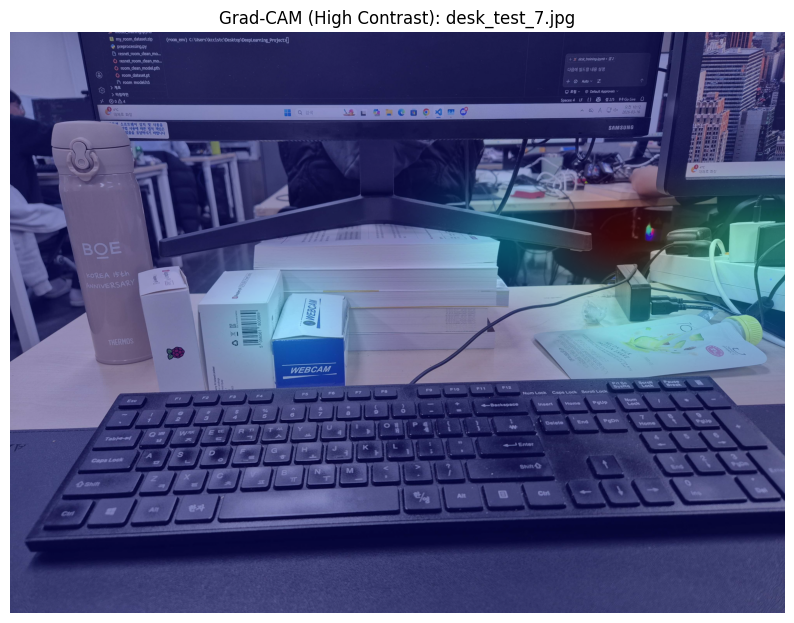

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# 1. 모델 불러오기
model_path = 'desk_resnet50_mixup_1.keras' # 가장 최근에 저장된 최고 모델
model = tf.keras.models.load_model(model_path)

# ResNet50의 마지막 컨볼루션 레이어 이름 찾기
# 보통 'conv5_block3_out' 입니다.
last_conv_layer_name = "conv5_block3_out" 

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):
    # 1. 원본 모델에서 'resnet50' 추출
    resnet_model = model.get_layer('resnet50')
    
    # 2. ResNet50 내부 특성 맵과 출력을 뽑는 모델 생성
    resnet_extractor = tf.keras.Model(
        inputs=resnet_model.inputs, 
        outputs=[resnet_model.get_layer(last_conv_layer_name).output, resnet_model.output]
    )

    with tf.GradientTape() as tape:
        # 🚨 [핵심 해결 방법] 
        # 모델 내부의 꼬여있는 전처리 레이어를 통과하지 않고, 여기서 직접 함수로 전처리합니다!
        x = tf.keras.applications.resnet50.preprocess_input(img_array)
        
        # 3. 전처리된 데이터를 바로 ResNet50에 통과시켜 특성 맵(conv_outputs) 추출
        conv_outputs, resnet_outputs = resnet_extractor(x)
        
        # 특성 맵의 변화 감시 시작
        tape.watch(conv_outputs)
        
        # 4. ResNet50 '이후'에 있는 안전한 레이어(GAP, Dense, Dropout)들만 찾아 통과시키기
        resnet_index = model.layers.index(resnet_model)
        out = resnet_outputs
        
        for layer in model.layers[resnet_index + 1:]:
            out = layer(out, training=False)
        
        # 5. 최종 판별값
        preds = out
        class_channel = preds[0, 0] 

    # 6. 기울기 계산 및 히트맵 생성
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 시각화를 위한 정규화 (0 ~ 1 사이로 맞춤)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

def display_gradcam(image_path, heatmap, alpha=0.6): # 👈 알파값을 0.4에서 0.6으로 올려 색상을 더 진하게 만듭니다.
    # ==========================================
    # 🌟 [대비 극대화 마법] 
    # 0~1 사이의 값을 3제곱합니다. 
    # (예: 0.9 -> 0.72로 살아남지만, 0.4 -> 0.06으로 확 죽어버립니다.)
    heatmap = np.power(heatmap, 3) 

    # 🌟 [노이즈 컷오프] 
    # 하위 20%의 애매한 관심도는 아예 0으로 지워버려서 배경을 깔끔하게 만듭니다.
    heatmap = np.where(heatmap < 0.2, 0.0, heatmap)
    # ==========================================

    # 원본 이미지 불러오기
    img = tf.keras.utils.load_img(image_path)
    img = tf.keras.utils.img_to_array(img)

    # 히트맵을 0~255 값으로 변환하고 컬러맵 적용
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # 히트맵 크기를 원본 이미지에 맞게 확대
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # 원본 이미지와 히트맵 합성
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # 결과 출력
    plt.figure(figsize=(10, 8))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title(f"Grad-CAM (High Contrast): {os.path.basename(image_path)}")
    plt.show()

# ==========================================
# 🚀 테스트 실행해보기
# ==========================================
test_img_path = 'desk_test_7.jpg' # 👈 두 번째 사진을 먼저 테스트해 봅시다!

# 전처리 및 예측
img = tf.keras.utils.load_img(test_img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)
# 주의: 이전에 테스트 코드에서 전처리를 지우셨다면 여기서도 지워야 합니다.
# (만약 모델 안에 전처리가 포함되어 있다면 아래 줄은 생략하세요)

# 히트맵 생성 및 시각화
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
display_gradcam(test_img_path, heatmap)

In [ ]:
import tensorflow as tf
import numpy as np
import os

# ==========================================
# 1. 3개의 모델 모두 불러오기
# ==========================================
print("🚀 3개의 AI 모델을 불러오는 중입니다. 잠시만 기다려주세요...")
try:
    model_room = tf.keras.models.load_model('resnet_room_clean_model.keras')
    model_desk_1 = tf.keras.models.load_model('desk_resnet50_mixup_1.keras')
    model_desk_best = tf.keras.models.load_model('desk_resnet50_mixupo_best.keras') # 파일명 오타(mixupo) 주의하세요!
    print("✅ 모든 모델 로드 완료!\n")
except Exception as e:
    print(f"❌ 모델을 불러오는 중 오류가 발생했습니다: {e}")
    exit()

# ==========================================
# 2. 결과 해석 함수 (사람의 직관에 맞춘 커스텀 채점표)
# ==========================================
def get_human_result(score):
    """
    0.0 ~ 1.0 사이의 점수를 사람의 언어로 번역합니다.
    """
    if score >= 0.85:
        return "DIRTY (더러움 🚨)", score * 100
    elif score >= 0.50:
        return "NORMAL (평범함/생활감 🧹)", score * 100
    else:
        # 0.5 미만이면 Clean으로 판단하되, 확신도는 반대로 계산
        return "CLEAN (깨끗함 ✨)", (1 - score) * 100

# ==========================================
# 3. 통합 이미지 예측 함수 정의
# ==========================================
def compare_models(image_path):
    if not os.path.exists(image_path):
        print(f"⚠️ 오류: '{image_path}' 경로에 이미지가 없습니다.")
        return

    # ------------------------------------------------
    # [A] 책상 모델용 컬러 이미지 준비 (224x224, 3채널 컬러)
    # ------------------------------------------------
    img_desk = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array_desk = tf.keras.utils.img_to_array(img_desk)
    img_array_desk = tf.expand_dims(img_array_desk, 0) # 배치 차원 추가

    # ------------------------------------------------
    # [B] 방 모델용 이미지 준비 (256x256, 3채널 흑백)
    # ------------------------------------------------
    img_room = tf.keras.utils.load_img(image_path, target_size=(256, 256))
    img_array_room = tf.keras.utils.img_to_array(img_room)
    img_array_room = tf.expand_dims(img_array_room, 0) 
    
    # 흑백으로 색을 뺀 뒤, 다시 3채널 형태로 포장하여 모델의 에러를 방지합니다.
    img_array_gray = tf.image.rgb_to_grayscale(img_array_room) 
    img_array_room_final = tf.image.grayscale_to_rgb(img_array_gray)

    # ------------------------------------------------
    # [C] 3개 모델 예측 수행
    # ------------------------------------------------
    pred_room = model_room.predict(img_array_room_final, verbose=0)[0][0]
    pred_desk_1 = model_desk_1.predict(img_array_desk, verbose=0)[0][0]
    pred_desk_best = model_desk_best.predict(img_array_desk, verbose=0)[0][0]

    # 결과 번역
    res_room, conf_room = get_human_result(pred_room)
    res_desk_1, conf_desk_1 = get_human_result(pred_desk_1)
    res_desk_best, conf_desk_best = get_human_result(pred_desk_best)

    # ------------------------------------------------
    # [D] 결과 출력
    # ------------------------------------------------
    print(f"┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓")
    print(f"   📸 테스트 이미지 : {os.path.basename(image_path)}")
    print(f"┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫")
    print(f"  [1] 방 청결도 모델 (256x256, 흑백)")
    print(f"      ▶ 결과: {res_room} / AI 확신도: {conf_room:.2f}% (Raw: {pred_room:.4f})")
    print(f"  [2] 책상 Mixup_1 모델 (224x224, 컬러)")
    print(f"      ▶ 결과: {res_desk_1} / AI 확신도: {conf_desk_1:.2f}% (Raw: {pred_desk_1:.4f})")
    print(f"  [3] 책상 Mixup_Best 모델 (224x224, 컬러)")
    print(f"      ▶ 결과: {res_desk_best} / AI 확신도: {conf_desk_best:.2f}% (Raw: {pred_desk_best:.4f})")
    print(f"┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛\n")


# ==========================================
# 4. 실제 테스트 실행해보기
# ==========================================
test_images = [
    'desk_test_1.jpg',
    'desk_test_2.jpg',
    'desk_test_3.jpg',
    'desk_test_4.jpg',
    'desk_test_5.jpg',
    'desk_test_6.jpg',
    'desk_test_7.jpg'
]

print("\n=== [ 🔍 3종 AI 모델 청결도 교차 검증 테스트 시작 ] ===")
for img_path in test_images:
    compare_models(img_path)

🚀 3개의 AI 모델을 불러오는 중입니다. 잠시만 기다려주세요...
❌ 모델을 불러오는 중 오류가 발생했습니다: No file or directory found at desk_resnet50_mixupo_best.keras

=== [ 🔍 3종 AI 모델 청결도 교차 검증 테스트 시작 ] ===
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
   📸 테스트 이미지 : desk_test_1.jpg
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
  [1] 방 청결도 모델 (256x256, 흑백)
      ▶ 결과: NORMAL (평범함/생활감 🧹) / AI 확신도: 71.41% (Raw: 0.7141)
  [2] 책상 Mixup_1 모델 (224x224, 컬러)
      ▶ 결과: CLEAN (깨끗함 ✨) / AI 확신도: 66.81% (Raw: 0.3319)
  [3] 책상 Mixup_Best 모델 (224x224, 컬러)
      ▶ 결과: CLEAN (깨끗함 ✨) / AI 확신도: 98.05% (Raw: 0.0195)
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
   📸 테스트 이미지 : desk_test_2.jpg
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
  [1] 방 청결도 모델 (256x256, 흑백)
      ▶ 결과: CLEAN (깨끗함 ✨) / AI 확신도: 84.90% (Raw: 0.1510)
  [2] 책상 Mixup_1 모델 (224x224, 컬러)
      ▶ 결과: NORMAL (평범함/생활감 🧹) / AI 확신도: 83.88% (Raw: 0.8388)
  [3] 책상 Mixup_Best 모델 (224x224, 컬러)
 

: 

NameError: name 'version' is not defined